## Dataset Overview

> 1. This dataset is called "E-Scooter Trips". It was found through the Chicago Data Portal, providing information on electric scooter trips taken in Chicago starting in May 2022. It includes information on start and end times, vendors, trip duration, distance, and locations. The link to the overview page is: https://data.cityofchicago.org/d/2i5w-ykuw


> 2. The original data set has over 12 million rows, which was extremely hard to download. I am using a filtered dataset that includes trips starting in January 2025 to the most recent data, which has 2,290,110 rows. There are 16 columns in this dataset.

> 3. For this EDA, I want to understand the factors that are associated with e-scooter trip counts, distance, and durations across different Chicago neighborhoods, vendors, dates, and times.

### Section 1 - Data Distribution & Summary Statistics

In [1]:
# Import Libraries 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Import dataset
df = pd.read_csv("scooter_data.csv")

# View dataset
display(df.head())

,Trip ID,Start Time,End Time,Trip Distance,Trip Duration,Vendor,Start Community Area Number,End Community Area Number,Start Community Area Name,End Community Area Name,Start Centroid Latitude,Start Centroid Longitude,Start Centroid Location,End Centroid Latitude,End Centroid Longitude,End Centroid Location
0,844b2cb1-43d2-4d73-bf21-0449bb195ff2,01/01/2025 10:00:00 AM,01/01/2025 10:00:00 AM,"1,247",375,Lime,65.0,65.0,West Lawn,West Lawn,41.769779,-87.726929,POINT (-87.72692933445077 41.7697790315413),41.769779,-87.726929,POINT (-87.72692933445077 41.7697790315413)
1,1c2a1f48-ba66-45c5-be99-e356ce5ae552,01/01/2025 10:00:00 AM,01/01/2025 10:00:00 AM,619,139,Lime,7.0,6.0,Lincoln Park,Lake View,41.922686,-87.649490,POINT (-87.64948972103552 41.922686117885036),41.944227,-87.655999,POINT (-87.65599892982172 41.944226870503705)
2,9225f0be-37d3-469e-bf56-fecbc809e21a,01/01/2025 10:00:00 AM,01/01/2025 10:00:00 AM,695,154,Lime,3.0,3.0,Uptown,Uptown,41.965812,-87.655879,POINT (-87.65587931915151 41.965812077713224),41.965812,-87.655879,POINT (-87.65587931915151 41.965812077713224)
3,1c382917-756a-49e4-1c38-2917756a49e4,01/01/2025 10:00:00 AM,01/01/2025 10:00:00 AM,"1,157",620,Lyft,24.0,24.0,West Town,West Town,41.901207,-87.676357,POINT (-87.67635712603918 41.90120673431559),41.901207,-87.676357,POINT (-87.67635712603918 41.90120673431559)
4,704466c2-2619-4b04-b83a-258791559d7b,01/01/2025 10:00:00 AM,01/01/2025 10:00:00 AM,509,160,Lime,59.0,59.0,Mckinley Park,Mckinley Park,41.829922,-87.672503,POINT (-87.67250270029349 41.82992225222832),41.829922,-87.672503,POINT (-87.67250270029349 41.82992225222832)


In [3]:
# View dataset information
display(df.shape) # size of dataset
display(df.dtypes) # inspecting column types

# Dropping columns I am not interested in
df = df.drop(columns = ["Start Centroid Latitude", "Start Centroid Longitude", "Start Centroid Location", "End Centroid Latitude", "End Centroid Longitude", "End Centroid Location", "Start Community Area Number", "End Community Area Number"])
# Already have neighborhood/community area names and distance, don't need coordinate information

(2290110, 16)

Trip ID                         object
Start Time                      object
End Time                        object
Trip Distance                   object
Trip Duration                   object
Vendor                          object
Start Community Area Number    float64
End Community Area Number      float64
Start Community Area Name       object
End Community Area Name         object
Start Centroid Latitude        float64
Start Centroid Longitude       float64
Start Centroid Location         object
End Centroid Latitude          float64
End Centroid Longitude         float64
End Centroid Location           object
dtype: object

#### Notes:
- "Trip Distance" and "Trip Duration" have string values that should be numerical. Need to convert these into float numbers.
- Also convert distance to miles and duration to minutes.
- "Start Time" and "End Time" contain the date and time in a single observation. Need to split these up and convert from object to datetime format. Extract day of the week from the dates as well.

In [4]:
# Data Cleaning

# Strip commas from Trip Duration
df["Trip Duration"] = df["Trip Duration"].str.replace(",", "")

# Strip commas from Trip Distance
df["Trip Distance"] = df["Trip Distance"].str.replace(",", "")

# Turn these features from object to float type 
df["Trip Duration"] = df["Trip Duration"].astype(float)
df["Trip Distance"] = df["Trip Distance"].astype(float)

# Convert Trip Distance from meters to miles
df["Trip Distance"] = df["Trip Distance"]/1609

# Covert Trip Duration from seconds to minutes
df["Trip Duration"] = df["Trip Duration"]/60

In [5]:
# More data cleaning
df["Time"] = pd.to_datetime(df["Start Time"]) # changing from object to datetime

# Splitting up date and times
df["Date"] = df["Time"].dt.date
df["Time"] = df["Time"].dt.hour

df = df.drop(columns = ["End Time", "Start Time"]) # Dropping these two columns, don't need these

# Creating day of the week column
df["Day of Week"] = pd.to_datetime(df["Date"]).dt.day_name()

In [6]:
# Re-display new dataset
display(df.head())

,Trip ID,Trip Distance,Trip Duration,Vendor,Start Community Area Name,End Community Area Name,Time,Date,Day of Week
0,844b2cb1-43d2-4d73-bf21-0449bb195ff2,0.775016,6.250000,Lime,West Lawn,West Lawn,10,2025-01-01,Wednesday
1,1c2a1f48-ba66-45c5-be99-e356ce5ae552,0.384711,2.316667,Lime,Lincoln Park,Lake View,10,2025-01-01,Wednesday
2,9225f0be-37d3-469e-bf56-fecbc809e21a,0.431945,2.566667,Lime,Uptown,Uptown,10,2025-01-01,Wednesday
3,1c382917-756a-49e4-1c38-2917756a49e4,0.719080,10.333333,Lyft,West Town,West Town,10,2025-01-01,Wednesday
4,704466c2-2619-4b04-b83a-258791559d7b,0.316346,2.666667,Lime,Mckinley Park,Mckinley Park,10,2025-01-01,Wednesday


In [7]:
# Summary statistics
display(df.describe().round(2))
display(df[["Trip Duration", "Trip Distance"]].median())

,Trip Distance,Trip Duration,Time
count,2290110.00,2290110.00,2290110.00
mean,1.20,10.01,15.23
std,11.24,11.62,4.65
min,0.00,-5.03,0.00
25%,0.44,3.77,12.00
50%,0.83,6.52,16.00
75%,1.49,11.70,19.00
max,8610.17,400.47,23.00


Trip Duration    6.516667
Trip Distance    0.825979
dtype: float64

#### Trip Distance
- Mean: 1.20 miles
- Median: 0.825 miles
- Min: 0 miles
- Max: 8610.17 miles
- Standard Deviation: 11.24

#### Trip Duration
- Mean: 10.01 minutes
- Median: 6.516 minutes
- Min: -5.03 minutes
- Max: 400.47 minutes
- Standard Deviation: 11.62

#### Notes
- It does not make sense that there is an observation with a duration of negative 5 seconds.
- Maximum values look like outliers. Values in the 75th percentile for both variables are way below the max values. Median values for both variables are lower than the mean, seem to be positively skewed.

In [8]:
# Value Counts
display(df["Vendor"].value_counts())
display(df["Day of Week"].value_counts())
display(df["Time"].value_counts())

with pd.option_context("display.max_rows", None): # output list too long, want to see as scrollable element
    display(df["Start Community Area Name"].value_counts())

with pd.option_context("display.max_rows", None): # same here
    display(df["End Community Area Name"].value_counts())

Vendor
Lime    1899934
Lyft     390176
Name: count, dtype: int64

Day of Week
Friday       380455
Saturday     346038
Thursday     336724
Tuesday      335973
Monday       313623
Wednesday    306025
Sunday       271272
Name: count, dtype: int64

Time
17    213164
16    205075
18    202747
15    179947
19    172594
14    147081
20    139085
13    133167
12    117237
21    113942
8     101354
22     96676
11     93635
9      93251
10     84534
23     74241
7      57598
0      29079
6      27476
5       8226
4          1
Name: count, dtype: int64

Start Community Area Name
Lake View                 211078
Lincoln Park              170856
Near North Side           145768
West Town                 136607
Near West Side            125313
Logan Square              101113
Loop                       93475
Belmont Cragin             71109
Austin                     67465
Uptown                     65899
Hyde Park                  48675
Humboldt Park              47020
Brighton Park              42915
North Center               42202
Edgewater                  41323
Rogers Park                40192
Chicago Lawn               38157
Gage Park                  35465
Lincoln Square             34697
Avondale                   33187
South Shore                30769
Irving Park                29621
New City                   28876
West Ridge                 28191
South Lawndale             27856
Chatham                    27340
Roseland                   25496
North Lawndale             25447
Greater Grand Crossing     24733
Portage Park     

End Community Area Name
Lake View                 209878
Lincoln Park              167682
Near North Side           149280
West Town                 134676
Near West Side            124733
Logan Square              100635
Loop                       94714
Belmont Cragin             69923
Austin                     68186
Uptown                     64812
Hyde Park                  48536
Humboldt Park              46325
North Center               42341
Edgewater                  41647
Brighton Park              40711
Rogers Park                40193
Chicago Lawn               38406
Gage Park                  36313
Lincoln Square             34675
Avondale                   33173
South Shore                31171
Irving Park                29889
West Ridge                 29185
New City                   27993
South Lawndale             27669
Chatham                    26507
North Lawndale             25619
Roseland                   25329
Greater Grand Crossing     24802
Portage Park       

In [9]:
# Look duplicate observations
df.duplicated().sum() # No duplicates found

np.int64(0)

In [10]:
# Checking for missing values
print(df.isnull().sum())


Trip ID                         0
Trip Distance                   0
Trip Duration                   0
Vendor                          0
Start Community Area Name    1643
End Community Area Name      2723
Time                            0
Date                            0
Day of Week                     0
dtype: int64


##### Only a total of 4,366 missing values were found. These observations make up only 0.19% of the dataset. They are not numerical values either, just the names of neighborhoods. Since critical variables like distance, duration, time, date, and day or not affected, I will keep these.

### Section 2 - Correlations & Group Comparisons

               Trip Duration  Trip Distance
Trip Duration       1.000000       0.087128
Trip Distance       0.087128       1.000000


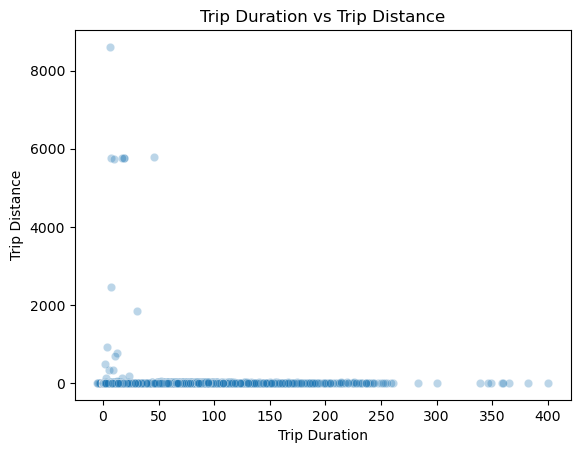

In [11]:
# Correlations
print(df[["Trip Duration", "Trip Distance"]].corr())   # correlation between Trip Duration and Distance

# Plotting Trip Duration and Trip Distance
sns.scatterplot(x="Trip Duration", y="Trip Distance", data=df, alpha=0.3)
plt.title("Trip Duration vs Trip Distance")
plt.xlabel("Trip Duration")
plt.ylabel("Trip Distance")
plt.show()

#### Notes:
- Correlation between trip distance and trip duration is very low (0.087). Intuitively, these variables would seem to have a stronger correlation, but the results say otherwise.
- The data has extreme outliers that pull the scale way out, which squishes the data points in the bottom left corner. Will set axis limits to zoom in on the main cluster.

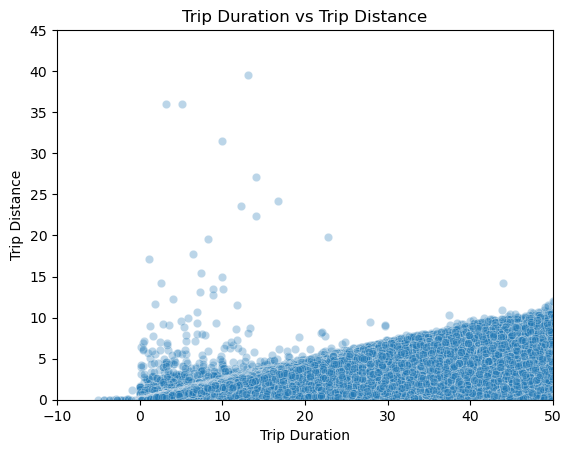

In [12]:
# Re-plotting with axis limits
sns.scatterplot(x="Trip Duration", y="Trip Distance", data=df, alpha=0.3)
plt.xlim(-10, 50)
plt.ylim(0, 45)
plt.title("Trip Duration vs Trip Distance")
plt.show()

#### Notes:
- New plot looks much better. Interesting shape, dense triangular cluster in bottom right which sugguests that a lot of trips have long durations but short distances. Could be indicative of being stuck in traffic (if not being used on sidewalk), round trips, leisure rides, people who stopped during the trip, etc.
- Some data points do not make sense. For example, the observations with distances ranging from 20-8000 miles in a short time seems nearly impossible. These could be GPS errors or data entry issues.

In [13]:
# Trips greater than 20 miles
far_trips = df[df["Trip Distance"] > 20]
display(far_trips)

,Trip ID,Trip Distance,Trip Duration,Vendor,Start Community Area Name,End Community Area Name,Time,Date,Day of Week
26178,500fe737-baba-4bd7-beb1-12225e5c15aa,343.888129,5.433333,Lime,Lake View,NaN,20,2025-01-04,Saturday
36150,666cc63e-605e-4820-bbef-a576542074b0,762.733996,12.800000,Lime,Lake View,Lake View,21,2025-01-04,Saturday
48572,85ff0d43-c597-4638-bc9f-5385b15a9dbc,124.797390,3.183333,Lime,Lake View,Lake View,21,2025-01-08,Wednesday
63484,4d5aea25-073e-4024-bb28-9470e1cfb0e9,23.627098,12.300000,Lime,Rogers Park,Dunning,17,2025-01-15,Wednesday
63883,93a8c83b-8b4f-4b15-b5b5-b8ab95e3c14e,27.149161,14.050000,Lime,Rogers Park,Rogers Park,19,2025-01-15,Wednesday
103364,2df527e7-291b-4321-b6bb-ab8dfa347b19,36.001865,5.100000,Lime,Rogers Park,NaN,18,2025-01-25,Saturday
134281,91745f1f-f5b0-440e-bfe1-ca0acd25944a,2469.543195,7.283333,Lime,Humboldt Park,West Garfield Park,7,2025-02-02,Sunday
168316,3561a5e7-8e64-496a-b477-b843ed8865ec,22.424487,14.033333,Lime,Rogers Park,Rogers Park,17,2025-02-10,Monday
189093,6936a9d7-4863-4ec4-b4fe-5eae093c59d4,696.591050,11.283333,Lime,NaN,Armour Square,12,2025-02-16,Sunday
245806,48499664-29ed-4e6e-b6b8-a6fc5e562858,52.967060,51.833333,Lime,Uptown,Uptown,14,2025-02-28,Friday


#### Notes:
- These definitely look like data errors. 2000 +miles on a trip is outrageous. Even 20 miles on a trip where the scooter remains in the same/closeby neighborhood also does not make sense.

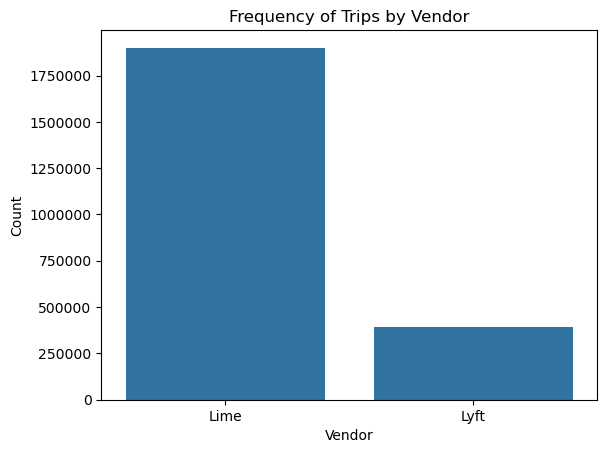

In [14]:
# Plotting frequency of trips by vendor
sns.countplot(x="Vendor", data=df)
plt.title("Frequency of Trips by Vendor")
plt.xlabel("Vendor")
plt.ylabel("Count")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

##### A lot of more Lime scooters than Lyft scooters available.

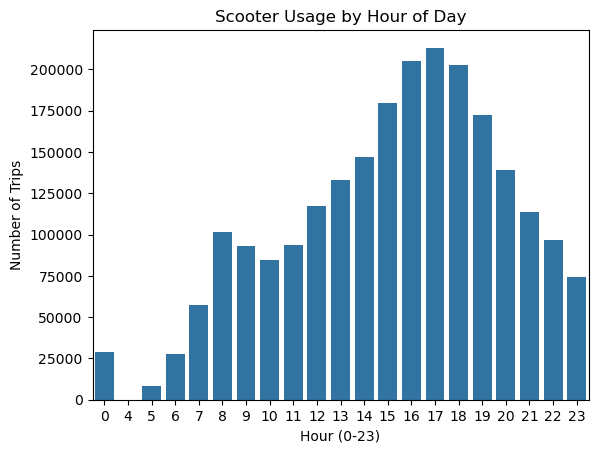

In [15]:
# Plotting scooter usage by hour of day
sns.countplot(x="Time", data=df)
plt.title("Scooter Usage by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Number of Trips")
plt.show()

##### Bar chart values are reasonable. Low frequencies at night time. Ramps up during morning rush hour when people are getting to work/school, also ramps up by afternoon/evening rush hour when people are getting out of work and school.

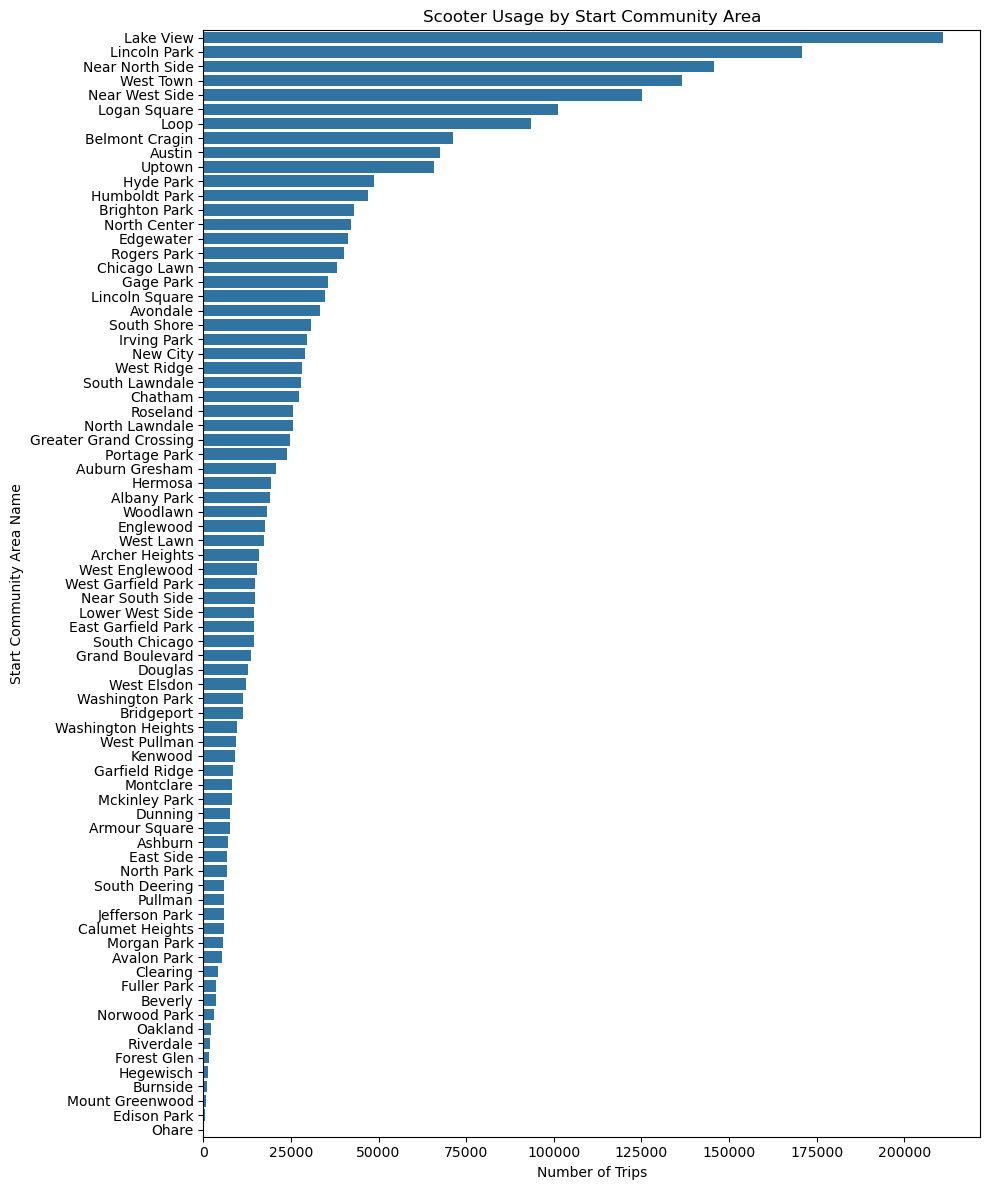

In [16]:
# Plotting scooter usage by start neighborhood
plt.figure(figsize=(10, 12))
sns.countplot(y="Start Community Area Name", data=df, order=df["Start Community Area Name"].value_counts().index)
plt.title("Scooter Usage by Start Community Area")
plt.xlabel("Number of Trips")
plt.tight_layout()
plt.show()

##### Provides insight into availability. The neighborhoods with the lower trip frequencies are all pretty much in the deep south side, with the exception of a few. The neighborhoods with the highest trips are on the north side and closer to downtown plus a few northwest/west side neighborhoods. Could be tied to socioeconomic factors and the distribution of resources across areas. Some areas are much easier to transit with scooters (wider side walks or designated bike lanes) that make their usage feel safer. Designated bike lanes (painted green lanes or divided by concrete) are usually seen in wealthier areas. Could also depend on access to public transit, and how often the buses on main streets come by or proximity to train stations.

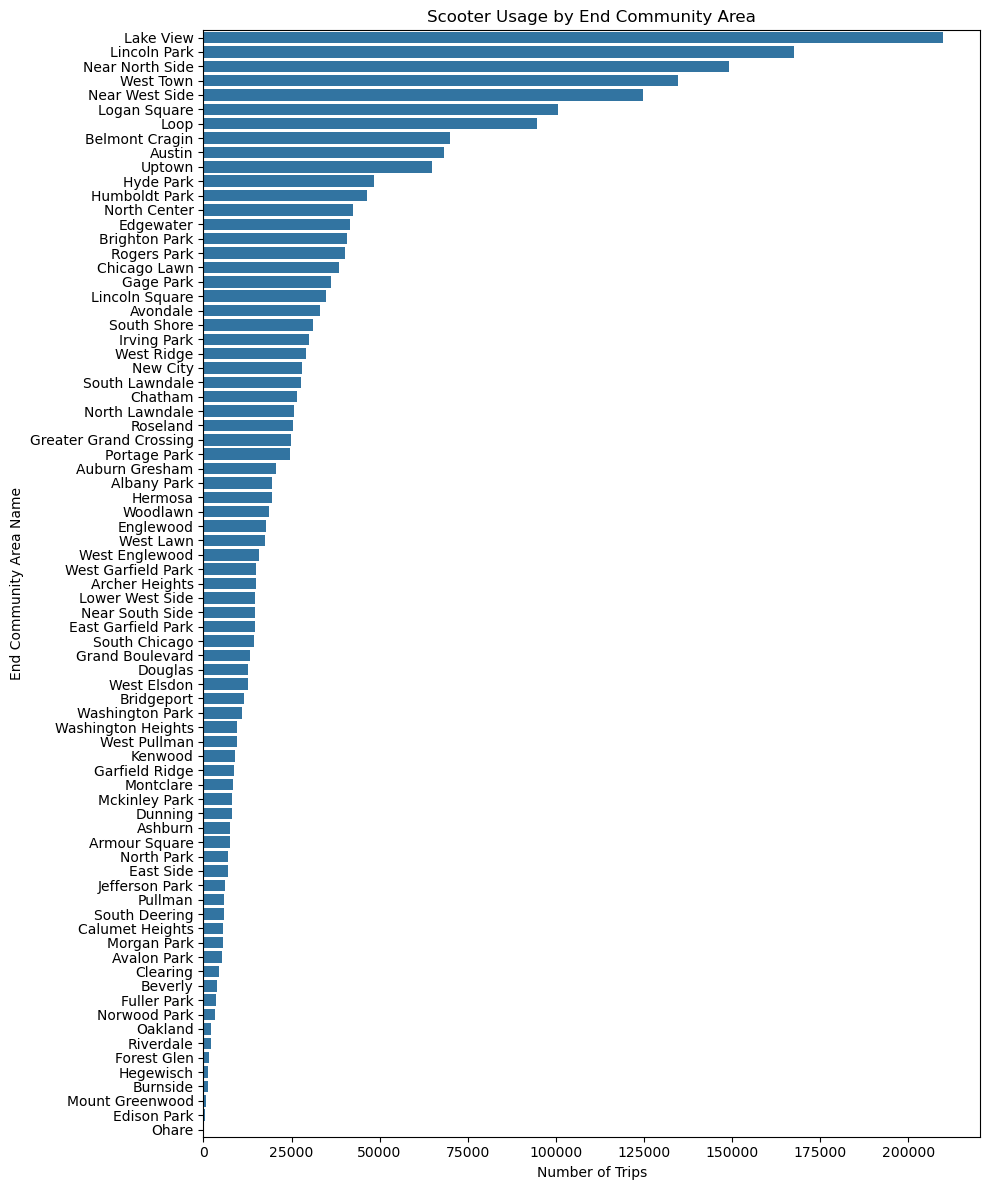

In [17]:
# Plotting scooter usage by end neighborhood
plt.figure(figsize=(10, 12))
sns.countplot(y="End Community Area Name", data=df, order=df["End Community Area Name"].value_counts().index)
plt.title("Scooter Usage by End Community Area")
plt.xlabel("Number of Trips")
plt.tight_layout()
plt.show()

##### Similar to above.

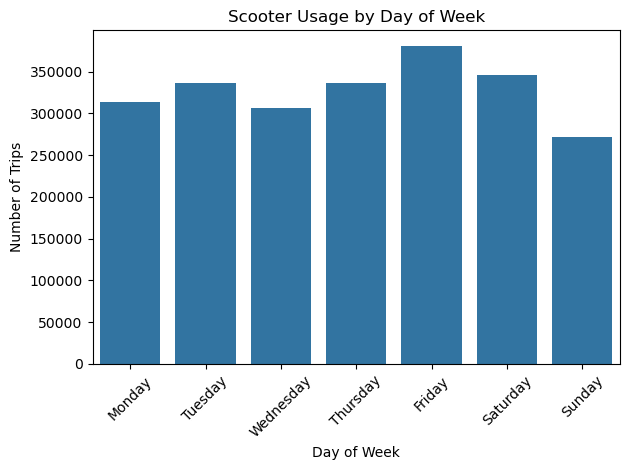

In [18]:
# Plotting usage frequencies across days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.countplot(x='Day of Week', data=df, order=day_order)
plt.title('Scooter Usage by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Scooter usage stays pretty consistent throughout the week, with a noticeable increase in trips on Fridays, and a decrease on Sundays.

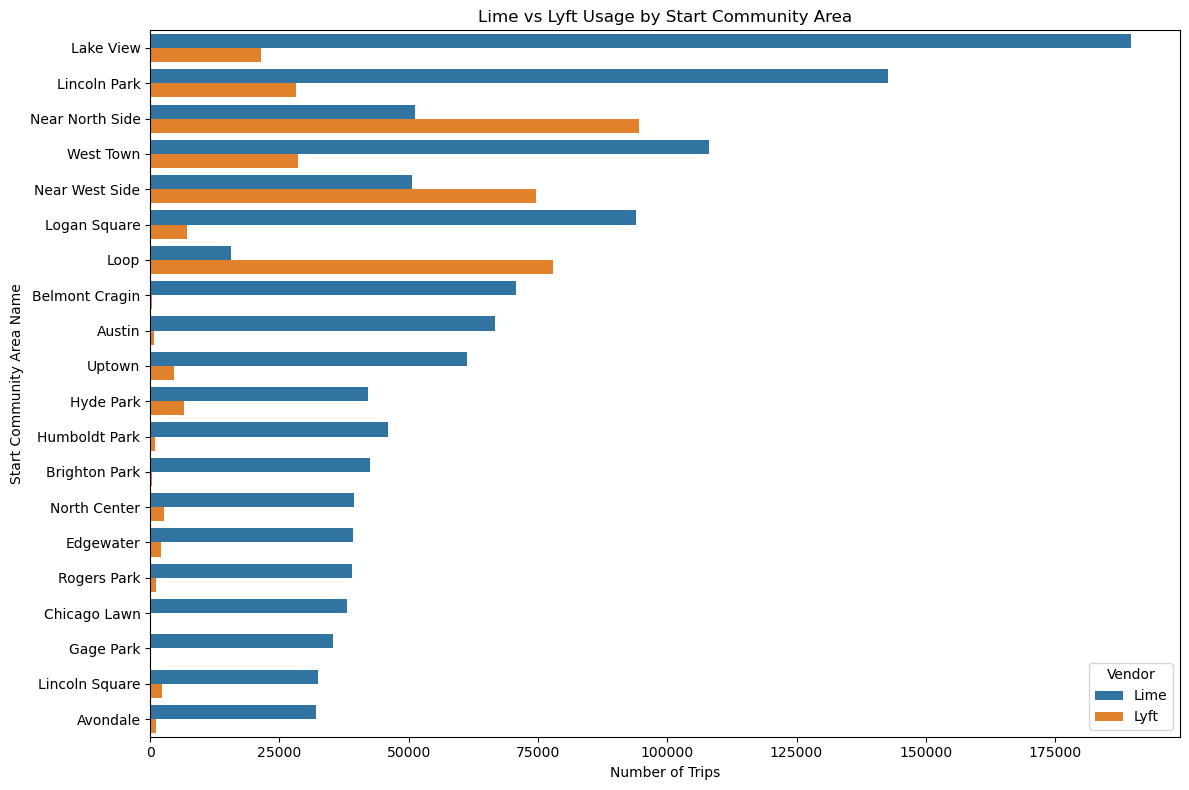

In [19]:
# Plotting usage of Lime vs Lyft scooters throughout neighborhoods (top 20)
top_20 = df['Start Community Area Name'].value_counts().head(20).index  # identifying top 20 areas with higher trips

plt.figure(figsize=(12, 8))
sns.countplot(y='Start Community Area Name', hue='Vendor', data=df, order=top_20)
plt.title('Lime vs Lyft Usage by Start Community Area')
plt.xlabel('Number of Trips')
plt.legend(title='Vendor')
plt.tight_layout()
plt.show()

##### Availablity of Lime vs Lyft scooters by area seems to vary. Lime is the predominant vendor in all areas except downtown (Loop), but the amount of trips with Lyft varies, with most being in neighborhoods closer to downtown.

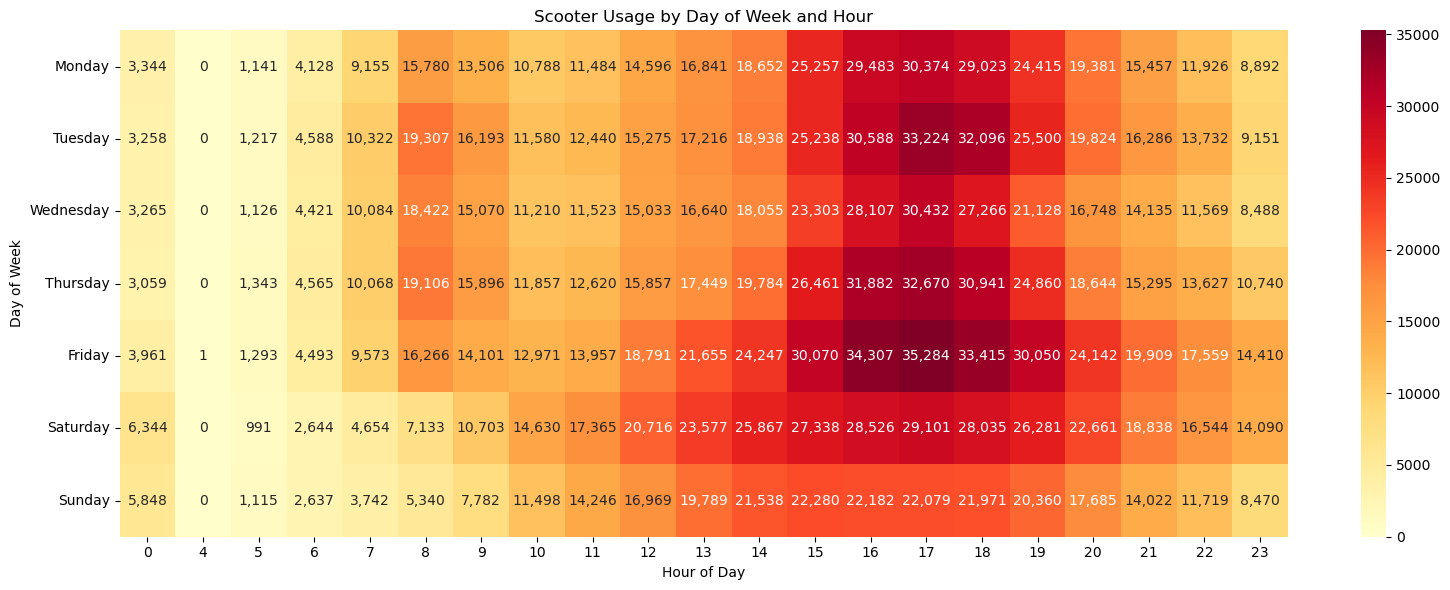

In [20]:
# Visualizing usage by Day of Week and Hour
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.groupby(['Day of Week', 'Time']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', fmt=',', annot=True)
plt.title('Scooter Usage by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

Peak usage happens between 3-6 PM (hours 15-18) across all days, with the highest being Friday at 5 PM with around 35,284 trips. This lines up with the evening commute. Maybe more people are excited it's Friday and tend to be more reckless and use scooters (they are scary in the city).

Weekdays show a morning commute increase around 8-9 AM (especially Tuesday-Thursday hitting 18,000-19,000), with then a stronger evening peak.

Weekends are different. Saturday and Sunday don't have that morning spike. Instead, usage gradually builds through the day, peaks in the early-mid afternoon (1-4 PM), and is more evenly spread. This can suggest recreational use rather than commuting.

Dead hours are 1-4 AM across all days, which drops to nearly zero at 4 AM.

Friday and Saturday have higher late-night usage, likely reflecting nightlife activity.

### Section 3 - Advanced Visualizations

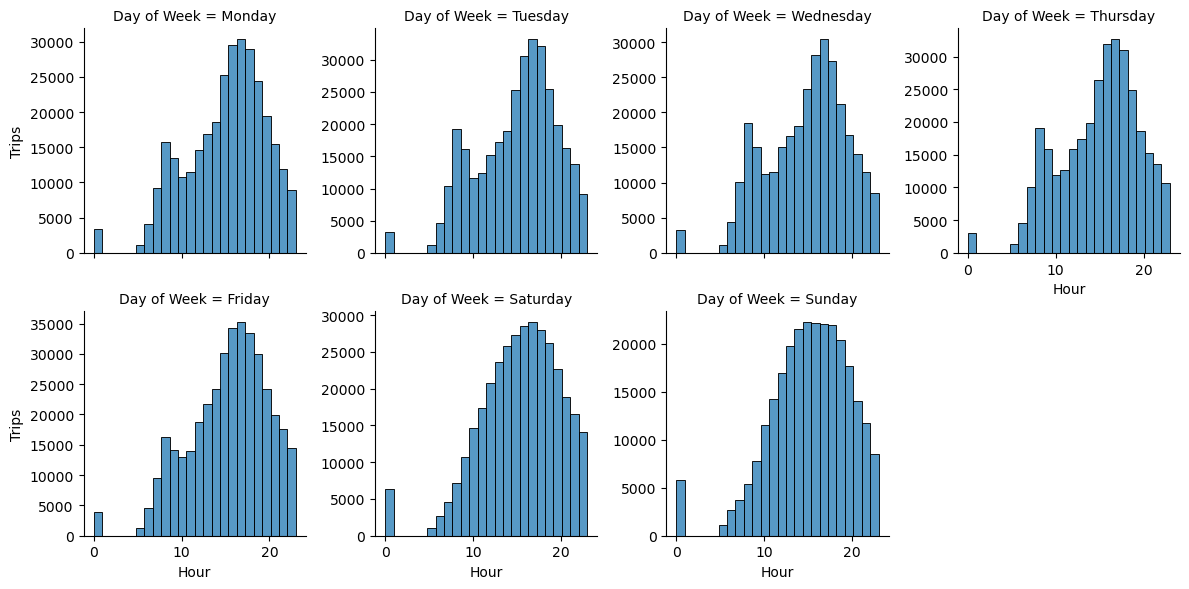

In [21]:
# Facet grid showing trip usage over time by day of the week
df['Day of Week'] = pd.Categorical(df['Day of Week'], categories=day_order, ordered=True)

grid = sns.FacetGrid(df, col='Day of Week', col_wrap=4, height=3, sharey=False)
grid.map(sns.histplot, 'Time', bins=24)
grid.set_axis_labels('Hour', 'Trips')
plt.tight_layout()
plt.show()

Shows similar information as earlier, where weekdays typically show commuter patterns with an early morning rush hour and evening rush hour. Weekends are different, and gradually increasing throughout the day, which could indicate recreational activities rather than commute schedules.

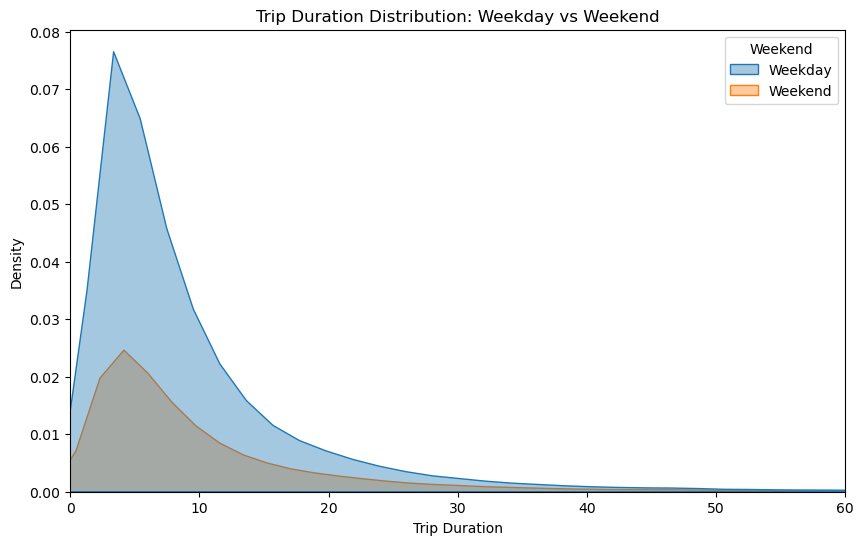

In [22]:
# KDE plot of trip duration distribution between weekday ands weekends
df['Weekend'] = df['Day of Week'].isin(['Saturday', 'Sunday']).map({True: 'Weekend', False: 'Weekday'}) # maps saturday and sunday and weekends

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Trip Duration', hue='Weekend', fill=True, alpha=0.4)
plt.xlim(0, 60)
plt.title('Trip Duration Distribution: Weekday vs Weekend')
plt.show()

This KDE plot compares trip duration between weekdays and weekends. It shows that weekday trips are heavily concentrated around 3-5 minutes, suggesting many are short but purposeful commutes. Weekend trips have a lower, flatter curve. It spreads out more into the 10-30 minute range. It suggests people tend to take longer and more leisurely rides on weekends.

/var/folders/_8/4vt5mksx773gr29dw_6_tgfm0000gn/T/ipykernel_66768/330903134.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df[df['Start Community Area Name'].isin(top_20)].groupby(


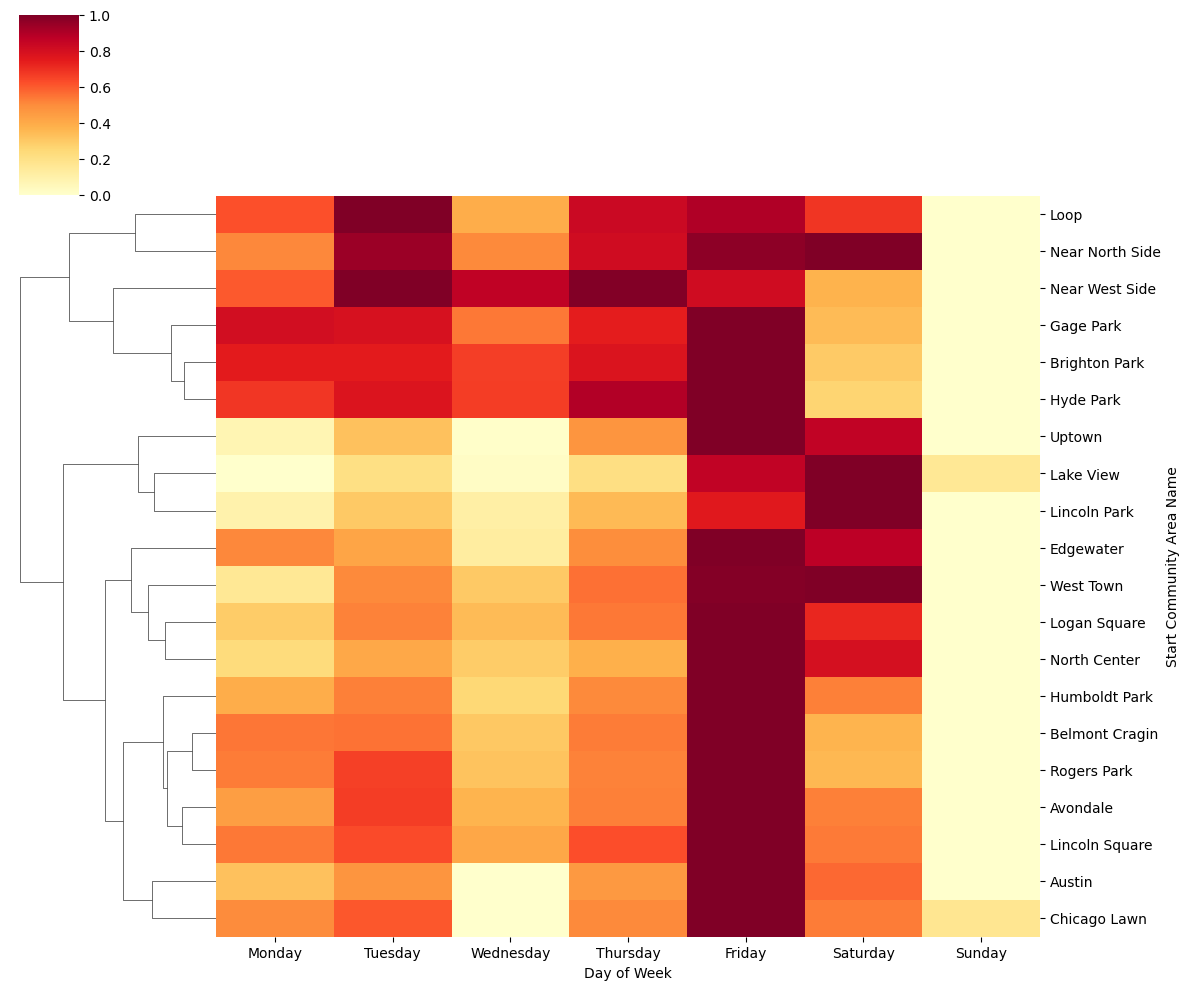

In [23]:
# Community areas by day of week
heatmap_data = df[df['Start Community Area Name'].isin(top_20)].groupby(
    ['Start Community Area Name', 'Day of Week']).size().unstack(fill_value=0)

heatmap_data = heatmap_data[day_order]

sns.clustermap(heatmap_data, cmap='YlOrRd', figsize=(12, 10), 
               standard_scale=0, col_cluster=False)
plt.show()

This clustermap shows scooter usage patterns across the top 20 community areas by day of week, with hierarchical clustering grouping neighborhoods with similar weekly patterns.

Friday is the dominant day across almost every community area.

The clustering reveals a few distinct groups. Loop, Near North Side, and Near West Side cluster together at the top, these are downtown/business areas with more consistent weekday usage.

Sunday is consistently the lowest usage day across nearly all neighborhoods, showing the lightest colors. 

Saturday varies more. The highest usage occurs in the Loop, Near North Side, Uptown, Lake View, Edgewater, and Lincoln Park. Interestingly enough, these neighborhoods all border Lake Michigan. It is very common for people to go bike riding, walking, running, and riding on scooters down the ledge (concrete part alongside the lake). It funny because you'll find the occasional divvy bike or lyft/lime scooter thrown inside the lake.

### Section 4 - Hypothesis Testing

#### Hypothesis Test 1:

**Null Hypothesis** (Ho): The trip count on the weekends vs weekdays is not statistically different.

**Alternative Hypothesis** (H1): The difference between the trip count on weekends vs weekdays is statistically different.

**Significance Level**: 0.05


In [24]:
# Two-Sample t-Test
from scipy import stats

group_a = df[df["Weekend"] == "Weekday"]["Date"].value_counts()
group_b = df[df["Weekend"] == "Weekend"]["Date"].value_counts()

t_stat, p_value = stats.ttest_ind(group_a, group_b)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 0.6050
p-value: 0.5460


I chose a Two Sample t-test because I am counting the total observations/trips that fall under Weekend and Weekday categories, and analyzing the difference between them, seeing whether it is statistically different from zero or not.

The test returned a p-value of 0.5460, which is greater than the alpha value of 0.05. This means we fail to reject the null hypothesis.

This means that there is no significant difference in total trip counts between Weekends or Weekdays. This makes sense because Chicago is a huge city, so scooters are not only being used to commute to school or work. People use them in various ways for so many purposes, whether it's to go clubbing, to go ride alongside the lake, to go to the store, etc. Therefore, these activities aren't exclusive to just weekends and weekdays since people live entirely different lives in a city with a huge population.

#### Hypothesis Test 2:

**Null Hypothesis** (Ho): The correlation between Trip Duration and Trip Distance is zero.

**Alternative Hypothesis** (H1): The correlation between Trip Duration and Trip Distance is statistically different from zero.

**Significance Level**: 0.05

In [25]:
# Pearson Correlation Test
r, p_value = stats.pearsonr(df["Trip Duration"], df["Trip Distance"])
print(f"Pearson r: {r:.4f}")
print(f"p-value: {p_value:.4f}")

Pearson r: 0.0871
p-value: 0.0000


I chose a Pearson Correlation Test because I wanted to see whether there was a correlation between two numerical variables. 

The test returned a p-value of essentially zero (p < 0.0001), meaning the correlation between trip duration and trip distance is statistically significant. Therefore, we reject the null hypothesis.

However, the Pearson r of 0.0871 means there is only a weak positive correlation. So although the correlation is statistically significant, trip duration is a poor predictor of trip distance, which seems counterintuitive. Other factors could be relevant, such as traffic congestion, weather, construction, etc.

### Section 5 - Final EDA Summary

**A) Summary of Major Findings**
Overall, this dataset was pretty interesting to work with. I had first seen these scooters pop up right before COVID when the city was testing them out in their pilot programs. There were many mixed reactions, but after half a decade, they've integrated into many people's lives.

One important pattern I noticed was the relationship between scooter usage and the hour of day, throughout the week. Peak usage occurs between 3-6 PM across all days, with the highest usage count being Friday at 5pm. Weekdays also show a morning commute increase around 8-9 AM (especially Tuesday-Thursday). when people are generally heading to work. It seems like a lot of weekday users tend to structure their days around a 9-5pm work/school schedule.

Dead hours (extremely low usage) occured from 1-4 AM across all days. 

Weekends were a bit different. There was no morning commute spike, instead usage gradually builds up through the day. There is also higher late-night usage, which could reflect nightlife activity. These patterns indicate that people may travel for leisure purposes, rather than for daily work/school activities.

Interestingly, scooter usage throughout the day and week can be related to the neighborhoods these rides take place in. Places like the Loop, Near North Side, Near West side and others have higher usage during the weekdays, as these are downtown areas that are more business-heavy. Saturday has high usage counts in the neighborhoods that border the lake, which make sense as it's super common to ride beside lake shore drive for leisure.

I conducted a hypothesis test to see whether there was a significant difference in scooter usage between weekends and weekdays. The test returned a p-value of 0.5460, meaning there is no statistically significant difference in total trip counts. This makes sense considering Chicago is a very large city, so scooter usage is high any day as it draws from a large population, who all differ in schedules and destinations. Weekdays and weekends are just as busy as eachother in their own ways.

I was also interested in the relationship between trip duration and trip distance. After conducting a hypothesis test, I was surprised to see that the correlation coefficient of 0.0871 was low. Although statistically significant, there is only a weak positive correlation. Therefore, trip duration may not be the best predictor of trip distance, which seems to be counter intuitive. Other factors could be relevant, such as traffic congestion, weather, construction, etc. 

**B) Limitations and Caveats**

One limitation of this dataset is that it only includes 2025 data. Originally, it contained data from 2022, but with over 12 million rows it was impossible to extract the dataset from its online source. 

Another limitation includes the multitude of outliers under the trip distance category. These could potentially be data errors, as 2000+ miles on a trip in under an hour is plain outrageous. However, after even filtering out these errors, the correlation between distance and duration remained low.

There are also several entries with missing values under Start Community Area Name and End Community Area Name. They seem to be missing completely at random, and main analyses did not draw on data in these columns. Therefore, I kept such observations since the rest of the data available was still useful enough to keep.

**C) Next Steps**

If I were to continue this analysis, I would like to continue analyzing data from previous years. There were two datasets from pilot programs in 2019 and 2020 which occurred during the pandemic. Along with the rest of the data starting in 2022, this could provide insight into how Chicagoans first reacted to scooters as they appeared on the streets, how scooter usage varied during the pandemic, and how it changed as restrictions eased up in Chicago. I would also look more into how these trips differ between the various months and seasons. I think this data would be suitable for building a model that predicts the number of trips on a certain date and time. There is plentiful data from every year that would make this possible, and it would only rely on the data/time variables and the number of observations.


